# Car Price Prediction – Advanced Models

## Objective
To improve upon the baseline model by applying advanced machine learning techniques, feature selection, and ensemble methods.

In [ ]:
#!pip install category_encoders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from category_encoders import TargetEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import make_column_selector
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import shap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import DBSCAN

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/adverts.csv")

# Data Description and Pre-Processing

In [ ]:
df = df.sample(frac=0.2, random_state=42)
df.head(10)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
332044,202010074692259,2826.0,69,Silver,Volkswagen,Sharan,USED,2019.0,23000,MPV,False,Diesel
173955,202009023198786,10601.0,19,Red,Nissan,Qashqai,USED,2019.0,16000,SUV,False,Petrol
367464,202007221569681,23000.0,58,Silver,Honda,Jazz,USED,2008.0,4799,Hatchback,False,Petrol
47695,202009113590641,9419.0,17,Silver,Volkswagen,Polo,USED,2017.0,11000,Hatchback,False,Petrol
210184,202010195186332,113250.0,16,Grey,Vauxhall,Insignia,USED,2016.0,5400,Hatchback,False,Diesel
389933,202010205222624,49000.0,60,Silver,Mercedes-Benz,C Class,USED,2011.0,6599,Saloon,False,Petrol
58172,202010014437830,135000.0,11,Silver,Toyota,Prius,USED,2011.0,5695,Hatchback,False,Petrol Hybrid
105521,202010305629889,0.0,NaN,Black,Volvo,XC40,NEW,NaN,38251,SUV,False,NaN
216591,202008011952460,62355.0,15,Silver,Mercedes-Benz,C Class,USED,2015.0,14500,Saloon,False,Diesel
273508,202008262946598,32340.0,17,Grey,BMW,1 Series,USED,2017.0,15495,Hatchback,False,Diesel


In [ ]:
#df = df.sample(n=10000, random_state=42).reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80401 entries, 332044 to 401584
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   public_reference       80401 non-null  int64  
 1   mileage                80380 non-null  float64
 2   reg_code               74097 non-null  object 
 3   standard_colour        79306 non-null  object 
 4   standard_make          80401 non-null  object 
 5   standard_model         80401 non-null  object 
 6   vehicle_condition      80401 non-null  object 
 7   year_of_registration   73823 non-null  float64
 8   price                  80401 non-null  int64  
 9   body_type              80209 non-null  object 
 10  crossover_car_and_van  80401 non-null  bool   
 11  fuel_type              80279 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 7.4+ MB


In [ ]:
df.describe()

,public_reference,mileage,year_of_registration,price
count,8.040100e+04,80380.000000,73823.000000,8.040100e+04
mean,2.020071e+14,37758.204056,2015.045948,1.721765e+04
std,1.673763e+10,34832.051458,7.007866,4.338016e+04
min,2.014120e+14,0.000000,1009.000000,2.000000e+02
25%,2.020090e+14,10428.250000,2013.000000,7.499000e+03
50%,2.020093e+14,28637.000000,2016.000000,1.256400e+04
75%,2.020102e+14,57000.000000,2018.000000,1.999900e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


In [ ]:
numerical_features=df.select_dtypes(include=["int64","float64"])
numerical_features.head()

,public_reference,mileage,year_of_registration,price
332044,202010074692259,2826.0,2019.0,23000
173955,202009023198786,10601.0,2019.0,16000
367464,202007221569681,23000.0,2008.0,4799
47695,202009113590641,9419.0,2017.0,11000
210184,202010195186332,113250.0,2016.0,5400


In [ ]:
categorical_features=df.select_dtypes(include=["object"])
categorical_features.head()

,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,body_type,fuel_type
332044,69,Silver,Volkswagen,Sharan,USED,MPV,Diesel
173955,19,Red,Nissan,Qashqai,USED,SUV,Petrol
367464,58,Silver,Honda,Jazz,USED,Hatchback,Petrol
47695,17,Silver,Volkswagen,Polo,USED,Hatchback,Petrol
210184,16,Grey,Vauxhall,Insignia,USED,Hatchback,Diesel


In [ ]:
df.shape

(80401, 12)

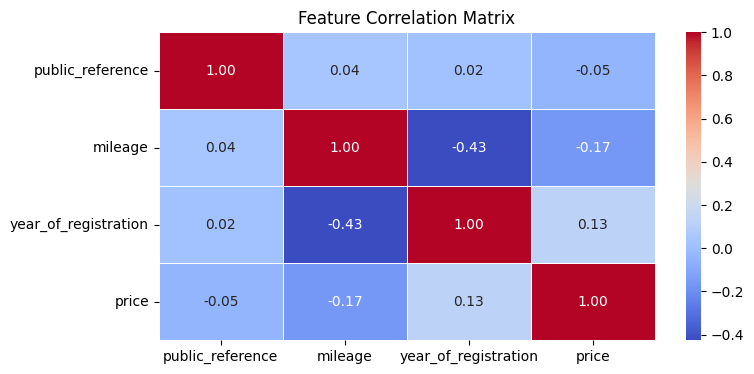

In [ ]:
correlation_matrix = numerical_features.corr()
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
ax.set_title("Feature Correlation Matrix");

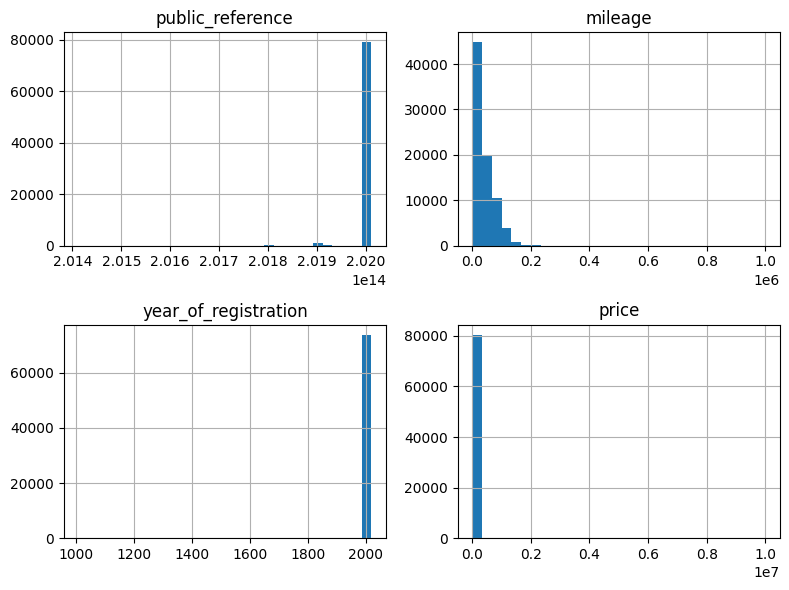

In [ ]:
df.hist(bins=30, figsize=(8,6))
plt.tight_layout()

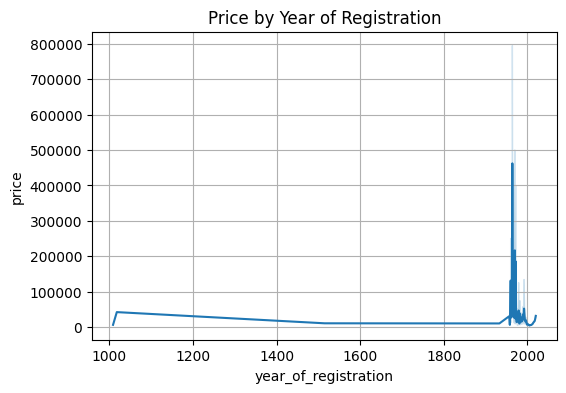

In [ ]:
plt.figure(figsize=(6, 4))
sns.lineplot(x='year_of_registration', y='price', data=df)
plt.title('Price by Year of Registration')
plt.grid(True)
plt.show()

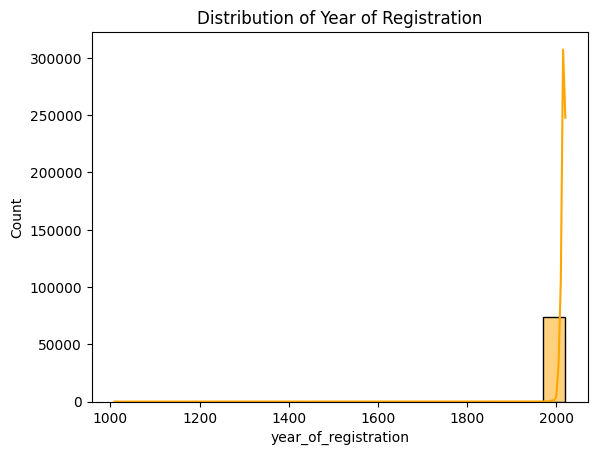

In [ ]:
sns.histplot(df['year_of_registration'], bins=20, kde=True, color = 'orange')
plt.title('Distribution of Year of Registration')
plt.show()

In [ ]:
df['year_of_registration'] = np.where(df['vehicle_condition'] == 'NEW', 2020, df['year_of_registration'])

In [ ]:
df = df[df['year_of_registration'] >= 1960]

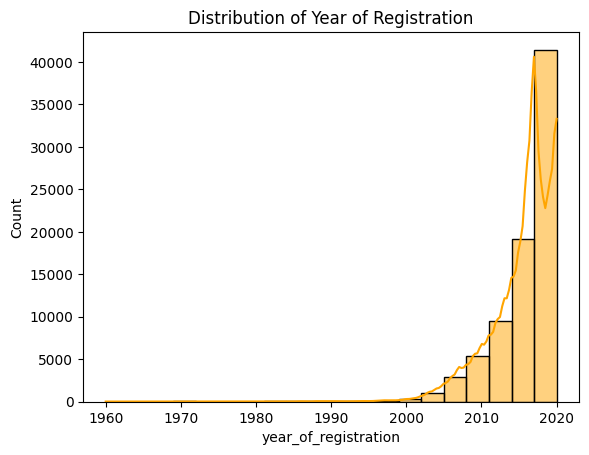

In [ ]:
sns.histplot(df['year_of_registration'], bins=20, kde=True, color = 'orange')
plt.title('Distribution of Year of Registration')
plt.show()

<Axes: xlabel='mileage'>

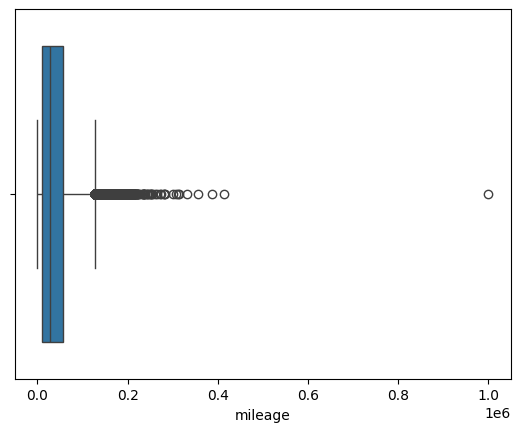

In [ ]:
sns.boxplot(data=df, x='mileage')

In [ ]:
df.loc[(df['vehicle_condition'] == 'NEW')&(df['mileage']>0), 'mileage']=0

In [ ]:
z_scores = np.abs((df['mileage'] - df['mileage'].mean()) / df['mileage'].std())
outliers = df[z_scores > 3]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 758


In [ ]:
df = df[z_scores <= 3]

<Axes: xlabel='mileage'>

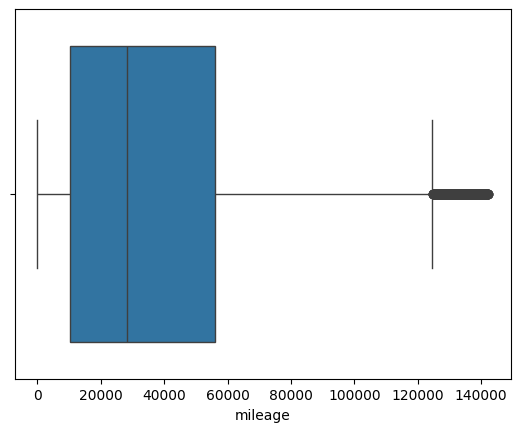

In [ ]:
sns.boxplot(data=df, x='mileage')

In [ ]:
current_year = datetime.datetime.now().year
df['vehicle_age'] = current_year - df['year_of_registration']


df['log_price'] = np.log(df['price'])


print("\nNew Features Added:")
df[['vehicle_age', 'log_price']].head()


New Features Added:


,vehicle_age,log_price
332044,6.0,10.043249
173955,6.0,9.680344
367464,17.0,8.476163
47695,8.0,9.305651
210184,9.0,8.594154


In [ ]:
df= df.drop(columns=["year_of_registration","price"])

In [ ]:
df

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,body_type,crossover_car_and_van,fuel_type,vehicle_age,log_price
332044,202010074692259,2826.0,69,Silver,Volkswagen,Sharan,USED,MPV,False,Diesel,6.0,10.043249
173955,202009023198786,10601.0,19,Red,Nissan,Qashqai,USED,SUV,False,Petrol,6.0,9.680344
367464,202007221569681,23000.0,58,Silver,Honda,Jazz,USED,Hatchback,False,Petrol,17.0,8.476163
47695,202009113590641,9419.0,17,Silver,Volkswagen,Polo,USED,Hatchback,False,Petrol,8.0,9.305651
210184,202010195186332,113250.0,16,Grey,Vauxhall,Insignia,USED,Hatchback,False,Diesel,9.0,8.594154
...,...,...,...,...,...,...,...,...,...,...,...,...
352633,202006220386966,48000.0,62,Blue,Suzuki,Jimny,USED,SUV,False,Petrol,13.0,9.053687
9460,202009163792686,36133.0,63,White,Hyundai,i20,USED,Hatchback,False,Petrol,12.0,8.459564
116353,202010144987045,35647.0,66,Blue,Honda,CR-V,USED,SUV,False,Diesel,9.0,9.506734
273649,202010104831397,0.0,NaN,Grey,Mercedes-Benz,GLA Class,NEW,SUV,False,Petrol,5.0,10.398123


In [ ]:
X, y = df.drop(columns='log_price'), df['log_price']
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42)

In [ ]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]
)
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())])

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", TargetEncoder(target_type='continuous')),
    ]
)
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', TargetEncoder(target_type='continuous'))])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, make_column_selector(dtype_include=np.number)),
        ("categorical", categorical_transformer, make_column_selector(dtype_include=object)),
    ],
    verbose_feature_names_out=False
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7f31e4147450>),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  TargetEncoder(target_type='continuous'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7f31e4144890>)],
                  verbose_feature_names_out=False)

# Automated Feature Selection

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed  = preprocessor.transform(X_test)

feature_selector = SequentialFeatureSelector(
    RandomForestRegressor(n_estimators=30, random_state=0, n_jobs=-1),
    n_features_to_select='auto',
    direction="forward",
).fit(X_train_processed, y_train)

In [ ]:
feature_selector.get_feature_names_out()

array(['x1', 'x2', 'x5', 'x6', 'x8'], dtype=object)

In [ ]:
selected_feature_names = preprocessor.get_feature_names_out()[feature_selector.get_support()]
print(selected_feature_names)

['mileage' 'vehicle_age' 'standard_make' 'standard_model' 'body_type']


In [ ]:
X_selected = feature_selector.transform(X_train_processed)
X_selected.shape

(63360, 5)

In [ ]:
X_train_selected = feature_selector.transform(X_train_processed)
X_test_selected  = feature_selector.transform(X_test_processed)

In [ ]:
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)

In [ ]:
regressor_model = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1).fit(X_selected, y_train)
cv_scores = cross_val_score(regressor_model, X_selected, y_train)
cv_scores.mean(), cv_scores.std()


(np.float64(0.9314190112651201), np.float64(0.0026037439886984685))

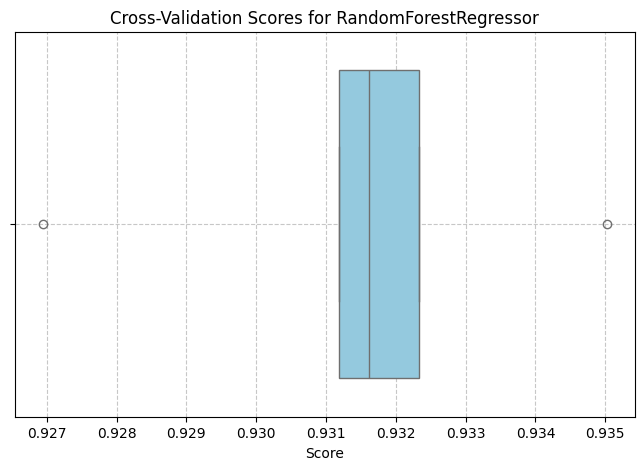

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_scores, orient='h', color='skyblue')
plt.title('Cross-Validation Scores for RandomForestRegressor')
plt.xlabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


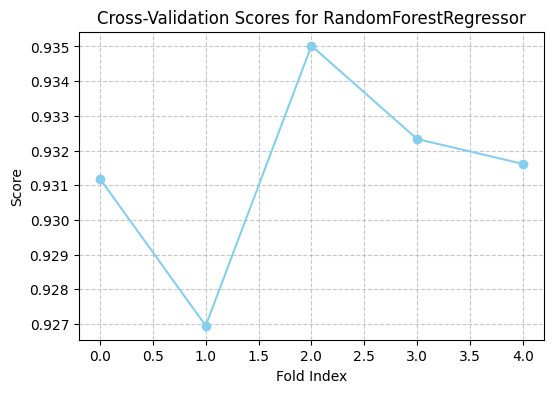

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(cv_scores, marker='o', linestyle='-', color='skyblue')
plt.title('Cross-Validation Scores for RandomForestRegressor')
plt.xlabel('Fold Index')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


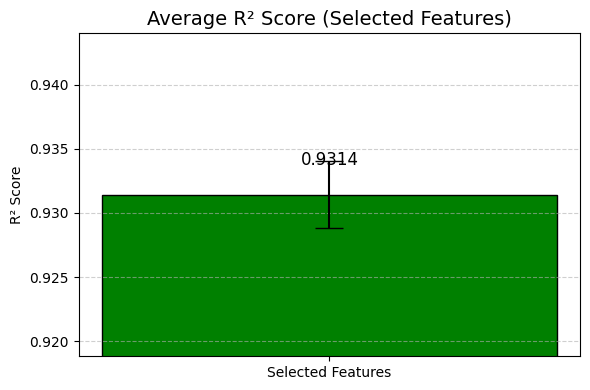

In [ ]:
plt.figure(figsize=(6, 4))

mean_sel = cv_scores.mean()
std_sel = cv_scores.std()

bars = plt.bar(['Selected Features'], [mean_sel], yerr=[std_sel], capsize=10, color='green', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.002, f"{height:.4f}", ha='center', va='bottom', fontsize=12)

plt.title("Average R² Score (Selected Features)", fontsize=14)
plt.ylabel("R² Score")
plt.ylim(mean_sel - std_sel - 0.01, mean_sel + std_sel + 0.01)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tree Ensembles

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_train_rf_pred = rf_model.predict(X_train_selected)
y_test_rf_pred  = rf_model.predict(X_test_selected)

In [ ]:
y_train_xgb_pred = xgb_model.predict(X_train_selected)
y_test_xgb_pred  = xgb_model.predict(X_test_selected)

In [ ]:
def evaluate_model(actual_values, predicted_values, label="Model"):
    r2 = r2_score(actual_values, predicted_values)
    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    print(f"\n{label}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

In [ ]:
evaluate_model(actual_values=y_train, predicted_values=y_train_xgb_pred, label="XGBoost: Train")
evaluate_model(actual_values=y_test, predicted_values=y_test_xgb_pred, label="XGBoost: Test")


XGBoost: Train
R² Score: 0.9415
MAE: 0.1463
RMSE: 0.2026

XGBoost: Test
R² Score: 0.9293
MAE: 0.1540
RMSE: 0.2223


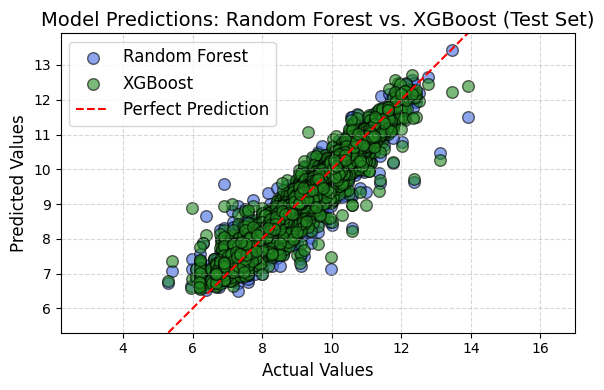

In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_test_rf_pred, alpha=0.6, label='Random Forest', color='royalblue', edgecolor='k', s=70)

plt.scatter(y_test, y_test_xgb_pred, alpha=0.6, label='XGBoost', color='forestgreen', edgecolor='k', s=70)

min_val = min(y_test.min(), y_test_rf_pred.min(), y_test_xgb_pred.min())
max_val = max(y_test.max(), y_test_rf_pred.max(), y_test_xgb_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.title("Model Predictions: Random Forest vs. XGBoost (Test Set)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.tight_layout()

plt.show()


# Ensemble of Tree Ensembles

In [ ]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                         random_state=42, n_jobs=-1, verbosity=0))
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1
)

stack_model.fit(X_train_selected, y_train)


y_stack_pred = stack_model.predict(X_test_selected)


r2 = r2_score(y_test, y_stack_pred)
mae = mean_absolute_error(y_test, y_stack_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_stack_pred))

print("Stacking Regressor Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Stacking Regressor Performance:
R² Score: 0.9361
MAE: 0.1431
RMSE: 0.2113


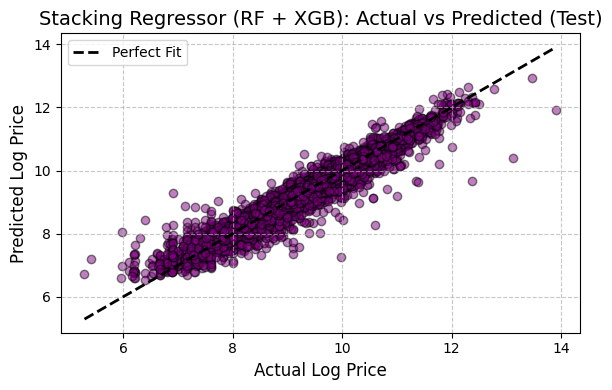

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_stack_pred, alpha=0.5, color='purple', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Log Price", fontsize=12)
plt.ylabel("Predicted Log Price", fontsize=12)
plt.title("Stacking Regressor (RF + XGB): Actual vs Predicted (Test)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Feature Importance

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_selected, y_train)

perm_importance = permutation_importance(
    rf,
    X_test_selected,
    y_test,
    n_repeats=30,
    random_state=0,
    scoring='r2'
)

In [ ]:
mean_permutation_importances = perm_importance.importances_mean

print("Mean Permutation Importance Scores:")
print(mean_permutation_importances)

Mean Permutation Importance Scores:
[0.16947385 0.46233217 0.14395992 0.51769999 0.04545563]


In [ ]:
features_selected = preprocessor.get_feature_names_out()[feature_selector.get_support()]

perm_df = pd.DataFrame({
    'Feature': np.array(features_selected),
    'Mean Importance': perm_importance.importances_mean
}).sort_values(by='Mean Importance', ascending=False)

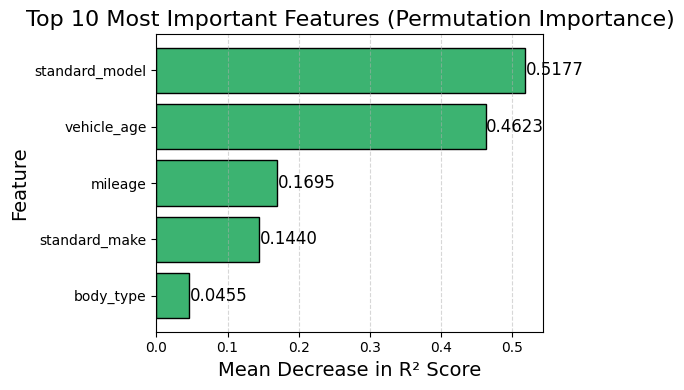

In [ ]:
plt.figure(figsize=(6, 4))

top_features = perm_df.head(10)

bars = plt.barh(
    top_features['Feature'],
    top_features['Mean Importance'],
    color='mediumseagreen',
    edgecolor='black'
)

plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in R² Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 10 Most Important Features (Permutation Importance)', fontsize=16)

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{width:.4f}', va='center', fontsize=12)

plt.tight_layout()
plt.show()

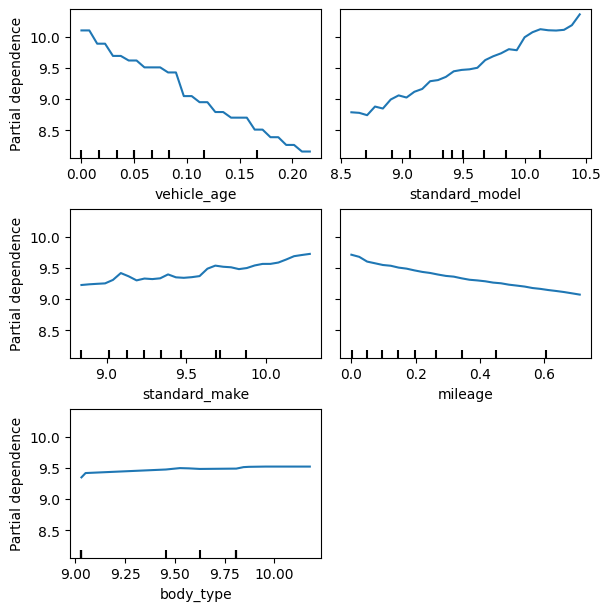

In [ ]:
fig, ax = plt.subplots(figsize=(6,6), constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    rf, X_test_selected_df, features=['vehicle_age', 'standard_model', 'standard_make', 'mileage', 'body_type'],
    kind='average',
    subsample=100, grid_resolution=30, n_jobs=2, random_state=0,
    ax=ax, n_cols=2
);

# SHAP

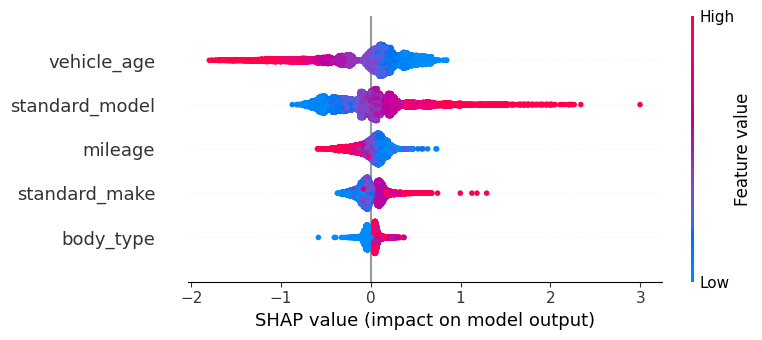

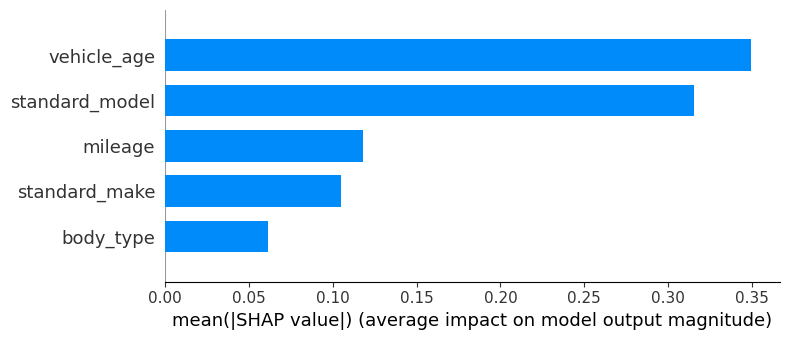

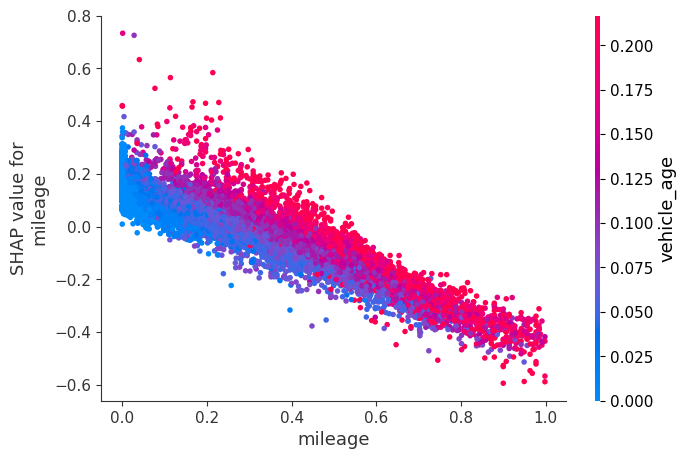

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_selected)

X_test_selected_df = pd.DataFrame(X_test_selected, columns=features_selected)

plt.figure(figsize=(6,6))
shap.summary_plot(shap_values, X_test_selected_df)

plt.figure(figsize=(6,6))
shap.summary_plot(shap_values, X_test_selected_df, plot_type='bar')

index_to_explain = 0

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[index_to_explain],
    X_test_selected_df.iloc[index_to_explain]
)
shap.save_html('local_explanation.html', force_plot)
display(force_plot)

shap.dependence_plot('mileage', shap_values, X_test_selected_df)


# Dimensionality Reduction (Linear)

In [ ]:
principal_component = PCA(n_components=2)
X_principal_component = principal_component.fit_transform(X_train_selected)

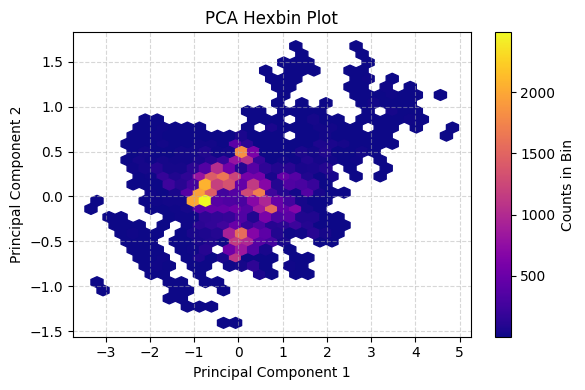

In [ ]:
plt.figure(figsize=(6, 4))
plt.hexbin(X_principal_component[:, 0], X_principal_component[:, 1], gridsize=30, cmap='plasma', mincnt=1)
plt.colorbar(label='Counts in Bin')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Hexbin Plot')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Dimensionality Reduction (Non-Linear)

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train_selected)

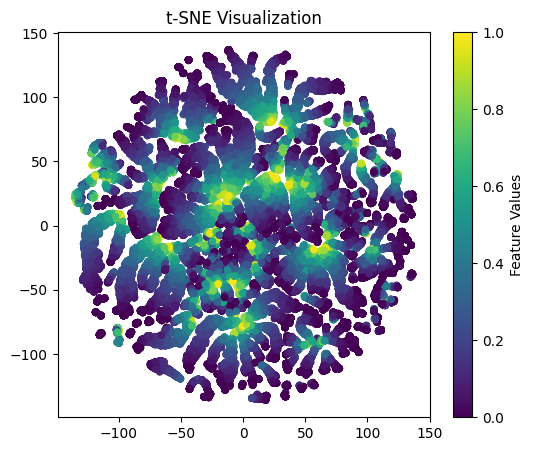

In [ ]:
plt.figure(figsize=(6, 5))
t_sub = X_train_selected[:, 0]
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=t_sub, cmap='viridis', s=20)
plt.title("t-SNE Visualization")
plt.colorbar(label='Feature Values')
plt.show()

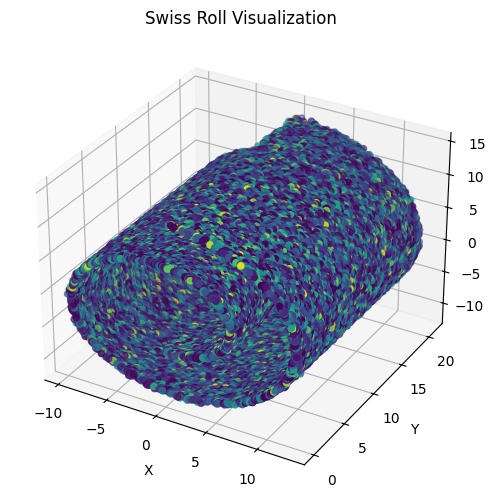

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

x = X_tsne[:, 0]
y = X_tsne[:, 1]

n_samples = len(x)
noise = 0.1

t = 3 * np.pi / 2 * (1 + 2 * np.linspace(0, 1, n_samples))
X = t * np.cos(t) + np.random.normal(scale=noise, size=n_samples)
Y = 21 * np.random.rand(n_samples)
Z = t * np.sin(t) + np.random.normal(scale=noise, size=n_samples)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, Z, c=t_sub, cmap='viridis', s=20)
ax.set_title("Swiss Roll Visualization")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# Polynomial Regression

In [ ]:
polynomial_regression_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])

polynomial_regression_pipeline.fit(X_train, y_train)

predicted_log_prices = polynomial_regression_pipeline.predict(X_test)

mse = mean_squared_error(y_test, predicted_log_prices)
r2 = r2_score(y_test, predicted_log_prices)

print("📊 Polynomial Regression (degree=2)")
print(f"MSE: {mse:.4f}")
print(f"R² : {r2:.4f}")

📊 Polynomial Regression (degree=2)
MSE: 0.0733
R² : 0.8951


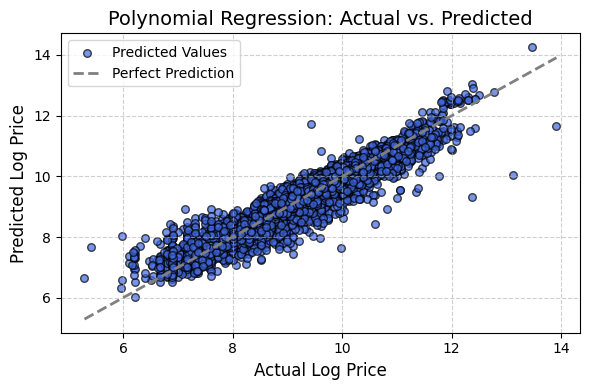

In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, predicted_log_prices,
            alpha=0.7,
            color='royalblue',
            edgecolors='k',
            s=30,
            label='Predicted Values'
           )

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         linestyle='--',
         color='gray',
         linewidth=2,
         label='Perfect Prediction'
        )

plt.xlabel("Actual Log Price", fontsize=12)
plt.ylabel("Predicted Log Price", fontsize=12)
plt.title("Polynomial Regression: Actual vs. Predicted", fontsize=14)

plt.legend(fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Clustering for Feature Engineering

In [ ]:
cl_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)

scaler = StandardScaler()
cl_scaled = scaler.fit_transform(cl_df)

dbscan = DBSCAN(eps=0.3, min_samples=5)
cluster = dbscan.fit_predict(cl_scaled)

cl_df['DBSCAN_Label'] = cluster
print(cl_df.head())

    mileage  vehicle_age  standard_make  standard_model  body_type  \
0  0.056251     0.016667       9.687715       10.063868   9.813346   
1  0.079066     0.050000       9.150269        9.351976   9.805433   
2  0.036549     0.000000       9.716521       10.332514   9.452866   
3  0.103189     0.050000       8.931823        9.334363   9.805433   
4  0.092597     0.016667       9.144160        8.739014   9.029779   

   DBSCAN_Label  
0             0  
1             0  
2             1  
3             0  
4             2  


In [ ]:
print(cl_df["DBSCAN_Label"].value_counts())

DBSCAN_Label
 2      27930
 0      17182
 1       6690
-1       4259
 5       2207
        ...  
 109        4
 97         3
 163        3
 160        2
 153        2
Name: count, Length: 178, dtype: int64


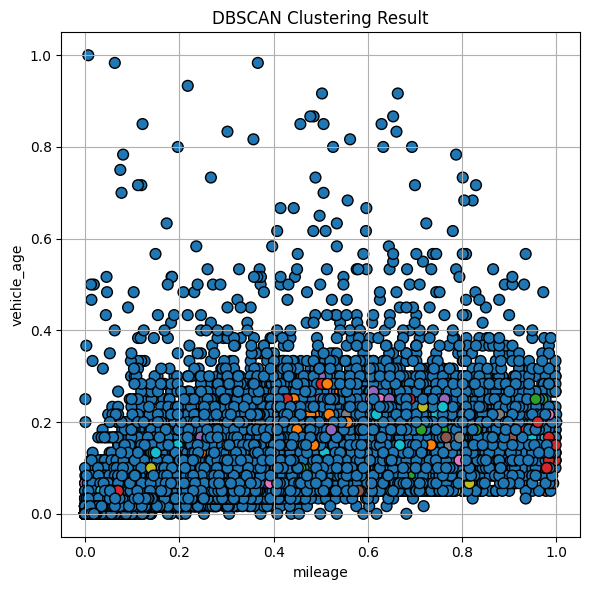

In [ ]:
feat_x = selected_feature_names[0]
feat_y = selected_feature_names[1]

plt.figure(figsize=(6, 6))
plt.scatter(
    cl_df[feat_x],
    cl_df[feat_y],
    c=cl_df['DBSCAN_Label'],
    cmap='tab10',
    s=60,
    edgecolor='k'
)

plt.title('DBSCAN Clustering Result')
plt.xlabel(feat_x)
plt.ylabel(feat_y)

plt.grid(True)
plt.tight_layout()
plt.show()